In [6]:
import random
import networkx as nx
import matplotlib.pyplot as plt

In [16]:
def gera_matriz(N, seed):
    random.seed(seed)

    matriz = [[random.randint(1, 3) for _ in range(N)] for _ in range(N)]

    return matriz


def distance(node1, node2):
    return max(abs(node1[0] - node2[0]),(abs(node1[1] - node2[1])))

N = 25
seed = 20

matriz = gera_matriz(N, seed)

G_base = nx.grid_2d_graph(N, N)

G = nx.DiGraph(G_base)


for i in range(N):
    for j in range(N):
        G.nodes[(i, j)]["type"] = matriz[i][j]

position = {(x,y): (y, -x) for x, y in G.nodes()}

nodes_C = [node for node, data in G.nodes(data=True) if data["type"] == 1]
nodes_S = [node for node, data in G.nodes(data=True) if data["type"] == 2]
nodes_T = [node for node, data in G.nodes(data=True) if data["type"] == 3]

successed_path = []
failed_path = []

In [17]:
def path_search(current_node, step, current_path):
    if step == 2: # 2 from circle to nearest square
        candidate_node = [
            s for s in nodes_S if 
                (s[0] == current_node[0]) or 
                (s[1] == current_node[1]) or 
                (abs(s[0] - current_node[0]) == abs(s[1] - current_node[1])) ]

    elif step == 3: # 3 from square to nearest triangle (only right or bellow)
        
        candidate_node = [
            t for t in nodes_T if 
                (t[1] > current_node[1] and t[0] == current_node[0]) or 
                (t[0] > current_node[0] and t[1] == current_node[1])
        ]
        
        print(current_node ,candidate_node)

    elif step == 4: # 4 from triangle to square (only diagonal)
        candidate_node = [
            s for s in nodes_S if 
            abs(s[0] - current_node[0]) == abs(s[1] - current_node[1]) and s != current_node
        ]

    elif step == 5: # 5 successed
        successed_path.append(current_path)
        return

    if not candidate_node: # no candidate node
        failed_path.append(current_path)
        return

    minimum_dist = min(distance(current_node, c) for c in candidate_node)
    closest_node = [c for c in candidate_node if distance(current_node, c) == minimum_dist]

    for next_node in closest_node:
        path_search(next_node, step + 1, current_path + [next_node])

In [18]:
for circle in nodes_C:
    path_search(circle, 2, [circle])

path_edges = set()
for path in successed_path + failed_path:
    for i in range((len(path))-1):
        path_edges.add((path[i], path[i+1]))

failed_nodes = list(set([c[-1] for c in failed_path]))
succeed_nodes = list(set([c[-1] for c in successed_path]))

(0, 3) [(0, 4), (0, 5), (0, 8), (0, 18), (0, 24), (4, 3), (11, 3), (12, 3), (16, 3), (17, 3), (19, 3), (20, 3), (23, 3)]
(1, 1) [(1, 5), (1, 6), (1, 11), (1, 19), (1, 22), (7, 1), (8, 1), (11, 1), (16, 1), (17, 1), (22, 1), (24, 1)]
(1, 2) [(1, 5), (1, 6), (1, 11), (1, 19), (1, 22), (4, 2), (5, 2), (7, 2), (9, 2), (12, 2), (20, 2), (22, 2)]
(1, 3) [(1, 5), (1, 6), (1, 11), (1, 19), (1, 22), (4, 3), (11, 3), (12, 3), (16, 3), (17, 3), (19, 3), (20, 3), (23, 3)]
(0, 7) [(0, 8), (0, 18), (0, 24), (2, 7), (3, 7), (4, 7), (5, 7), (12, 7), (14, 7), (18, 7), (22, 7)]
(1, 7) [(1, 11), (1, 19), (1, 22), (2, 7), (3, 7), (4, 7), (5, 7), (12, 7), (14, 7), (18, 7), (22, 7)]
(1, 8) [(1, 11), (1, 19), (1, 22), (5, 8), (10, 8), (11, 8), (12, 8), (18, 8), (19, 8), (20, 8)]
(0, 11) [(0, 18), (0, 24), (1, 11), (2, 11), (8, 11), (10, 11), (14, 11), (21, 11)]
(0, 12) [(0, 18), (0, 24), (2, 12), (12, 12), (13, 12), (17, 12), (19, 12), (23, 12), (24, 12)]
(0, 12) [(0, 18), (0, 24), (2, 12), (12, 12), (13, 12

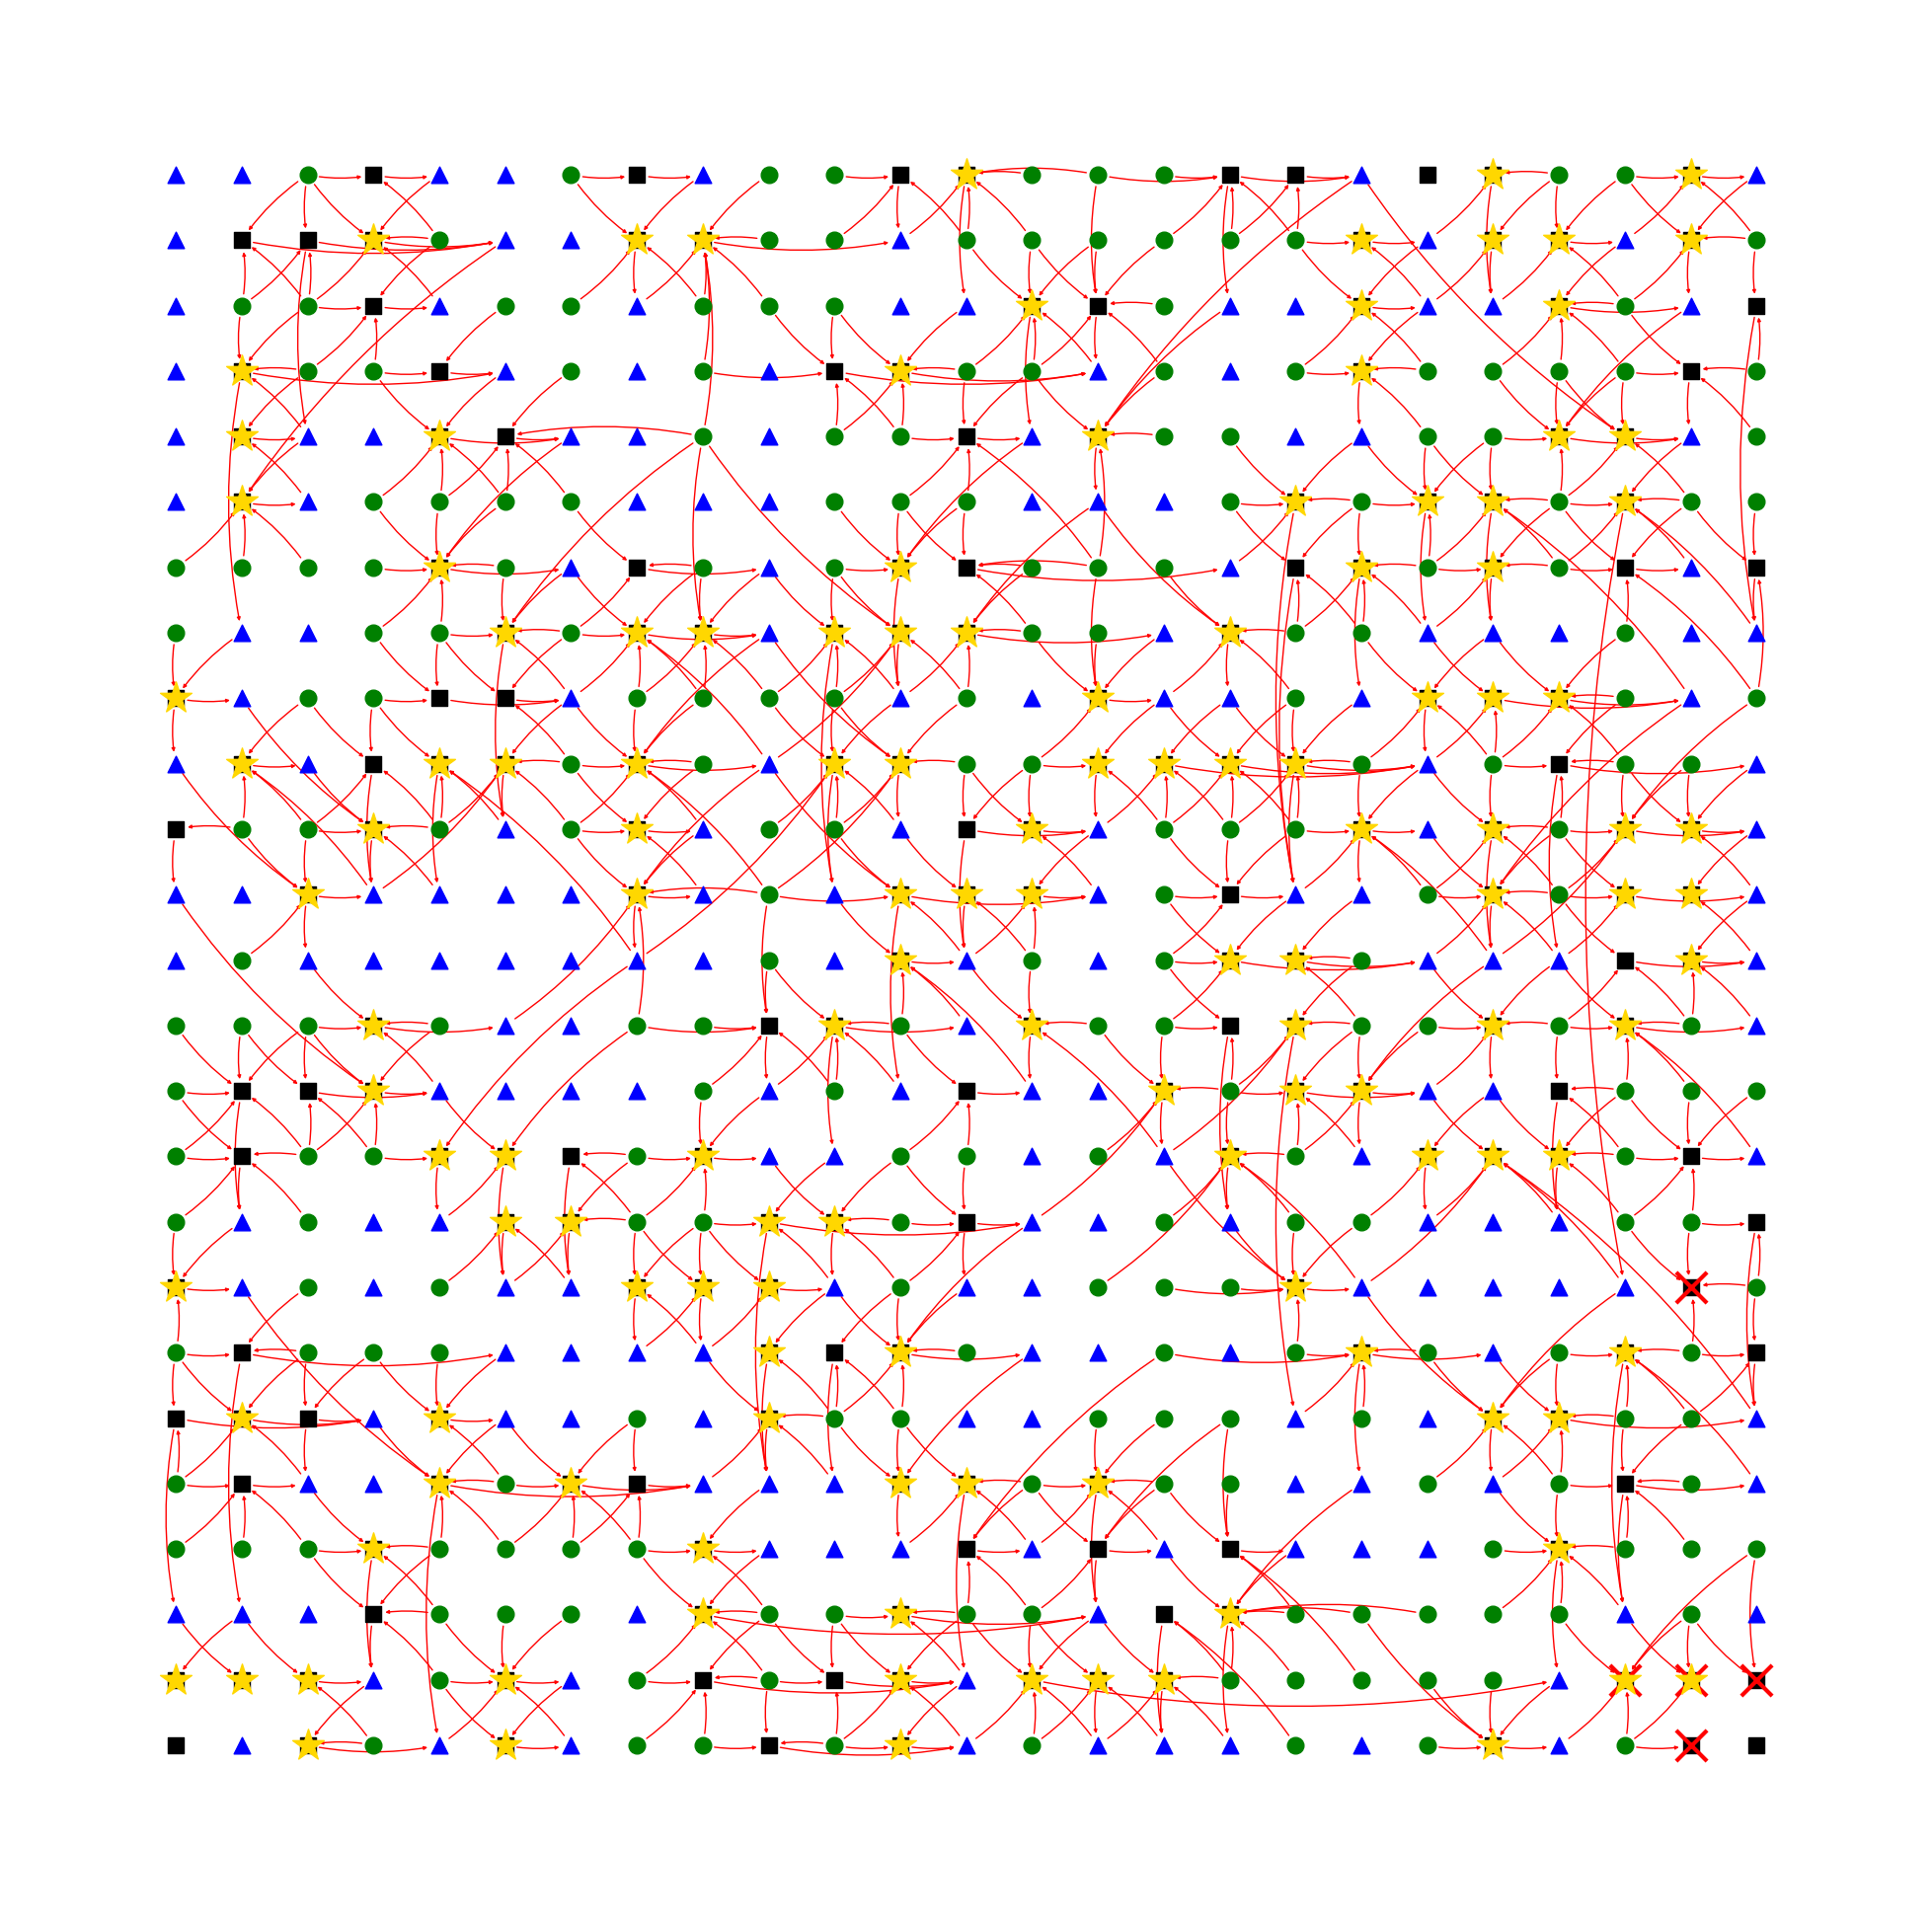

In [19]:
figsize = max(10, N * 1.0)

node_size = max(100, 3600 / N)

edge_width = max(1, 12 / N)
arrow_width = max(5, 120 / N)
X_size = node_size * 3.5
star_size = node_size * 4
espessura_x = max(1, 18 / N)

plt.figure(figsize=(figsize, figsize))

nx.draw_networkx_nodes(
    G,
    pos=position,
    nodelist=nodes_C,
    node_color="green",
    node_size=node_size,
    node_shape="o"
)

nx.draw_networkx_nodes(
    G,
    pos=position,
    nodelist=nodes_S,
    node_color="black",
    node_size=node_size,
    node_shape="s"
)

nx.draw_networkx_nodes(
    G,
    pos=position,
    nodelist=nodes_T, 
    node_color="blue",
    node_size=node_size,
    node_shape="^"
)


if failed_nodes:
    nx.draw_networkx_nodes(
        G,
        pos=position,
        nodelist=failed_nodes,
        node_color="red",
        node_size=X_size,
        node_shape="x",
        linewidths=3
    )
    
if succeed_nodes:
    nx.draw_networkx_nodes(
        G,
        pos=position,
        nodelist=succeed_nodes,
        node_color="gold",
        node_size=star_size,
        node_shape="*"
    )

nx.draw_networkx_edges(
    G, 
    pos=position, 
    edgelist=list(path_edges), 
    edge_color="red", 
    width=edge_width,
    arrows=True,
    arrowsize=arrow_width,
    connectionstyle="arc3,rad=0.1",
)

plt.axis("off")
plt.show()